In [76]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re
from pathlib import Path

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

In [93]:
dx.refresh_bokeh()

Loading BokehJS ...

In [86]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/pump_sweep'
base_folder = '/home/jovyan/BACKUP/Pacome/pump_sweep'

In [79]:
fc = 9.30154207e+09
fm = 1.21e+06 + 881

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'pump_freq']


/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/steele-lab-analysis-functions/analysis_functions/users/pacome/_format_data_xarray.py:79: UserWarning: rename 'pump_freq' to 'pump_freq' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data = data.rename({old_dim: new_dim})


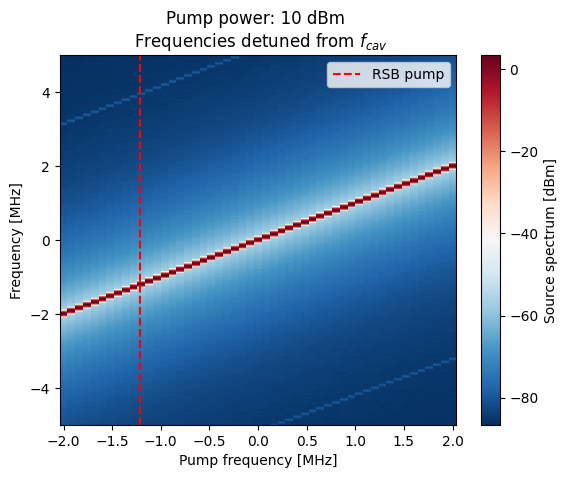

In [151]:
file_folder = '2026-06-29_12.57.37_0002_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'pump_freq':['pump_freq', 'GHz', 1e9]}

data_source = format_data_xarray(data, tool='SA', translator=translator)

plt.figure()
plt.pcolormesh((data_source.pump_freq.values - np.full(len(data_source.pump_freq.values), fc*1e-09))*1e3, (data_source.freq.values - np.full(len(data_source.freq.values), fc*1e-09))*1e3, data_source.spect.values,
              cmap = 'RdBu_r')
plt.axvline(-fm * 1e-06, linestyle='--', color='red', label='RSB pump')
plt.colorbar(label = 'Source spectrum [dBm]')
plt.xlabel('Pump frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Pump power: 10 dBm \n Frequencies detuned from $f_{cav}$')
plt.legend()
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'pump_freq']


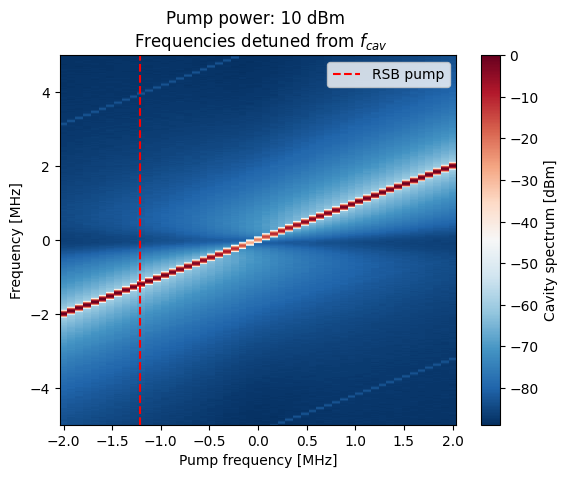

In [152]:
file_folder = '2026-06-29_11.40.41_0001_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'pump_freq':['pump_freq', 'GHz', 1e9]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)

plt.figure()
plt.pcolormesh((data_cavity.pump_freq.values - np.full(len(data_cavity.pump_freq.values), fc*1e-09))*1e3, (data_cavity.freq.values - np.full(len(data_cavity.freq.values), fc*1e-09))*1e3, data_cavity.spect.values,
              cmap = 'RdBu_r')
plt.axvline(-fm * 1e-06, linestyle='--', color='red', label='RSB pump')
plt.colorbar(label = 'Cavity spectrum [dBm]')
plt.xlabel('Pump frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Pump power: 10 dBm \n Frequencies detuned from $f_{cav}$')
plt.legend()
plt.show()


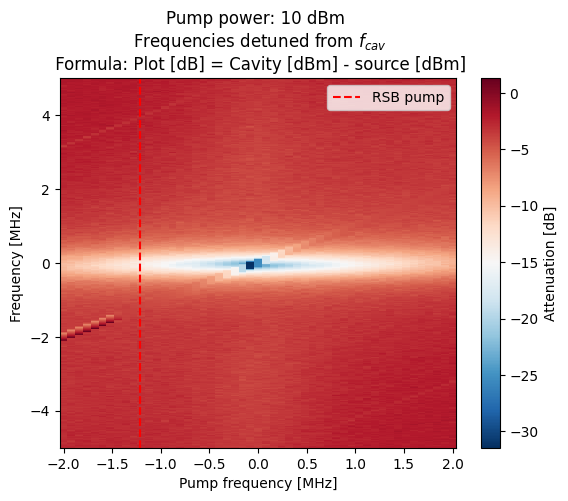

In [153]:
spect_diff = data_cavity.spect.values - data_source.spect.values

plt.figure()
plt.pcolormesh((data_cavity.pump_freq.values - np.full(len(data_cavity.pump_freq.values), fc*1e-09))*1e3, (data_cavity.freq.values - np.full(len(data_cavity.freq.values), fc*1e-09))*1e3, spect_diff,
              cmap = 'RdBu_r')
plt.axvline(-fm * 1e-06, linestyle='--', color='red', label='RSB pump')
plt.colorbar(label = 'Attenuation [dB]')
plt.xlabel('Pump frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Pump power: 10 dBm \n Frequencies detuned from $f_{cav}$ \n Formula: Plot [dB] = Cavity [dBm] - source [dBm]')
plt.legend()
plt.show()

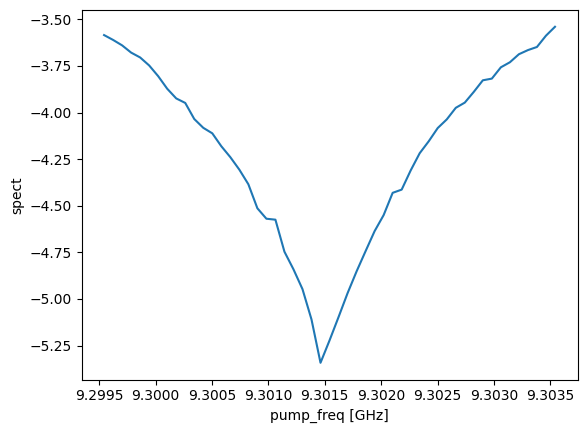

In [154]:
spect_diff = data_cavity.spect - data_source.spect
spect_diff.mean('freq').plot()

In [155]:
fc

9301542070.0

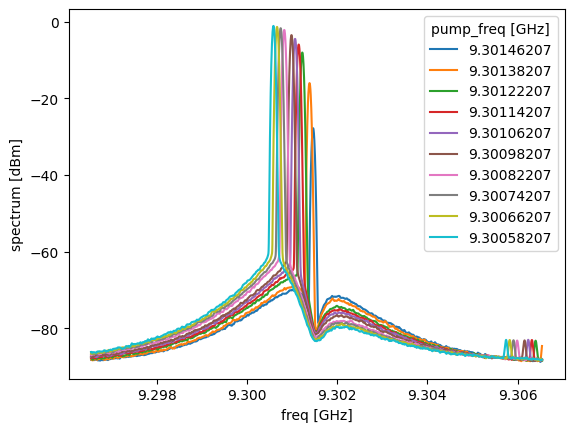

In [159]:
#data_cavity.sel(pump_freq=1, method='nearest').spect.plot() 
data_cavity.sel(pump_freq=np.linspace(fc/1e9-0.0001,fc/1e9-0.001,10), method='nearest').spect.plot.line(x='freq');

# Pump power sweep

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'pump_power']


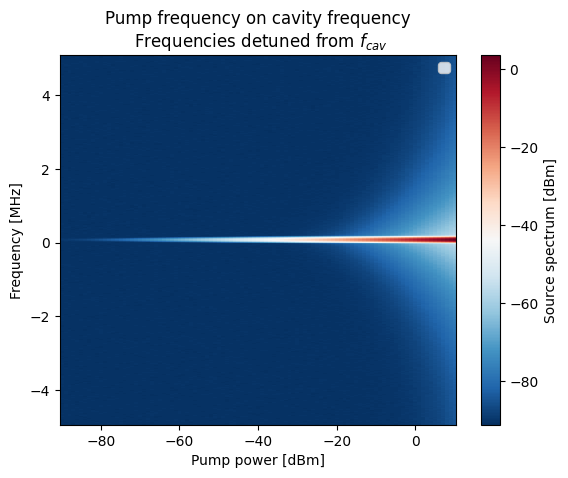

In [119]:
file_folder = '2026-06-30_13.40.12_0005_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Pump power (dBm)':['pump_power', 'dBm', 1]}

data_source = format_data_xarray(data, tool='SA', translator=translator)

plt.figure()
plt.pcolormesh(data_source.pump_power.values, (data_source.freq.values - np.full(len(data_source.freq.values), fc*1e-09))*1e3, data_source.spect.values,
              cmap = 'RdBu_r')
plt.colorbar(label = 'Source spectrum [dBm]')
plt.xlabel('Pump power [dBm]')
plt.ylabel('Frequency [MHz]')
plt.title('Pump frequency on cavity frequency\n Frequencies detuned from $f_{cav}$')
plt.legend()
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'pump_power']


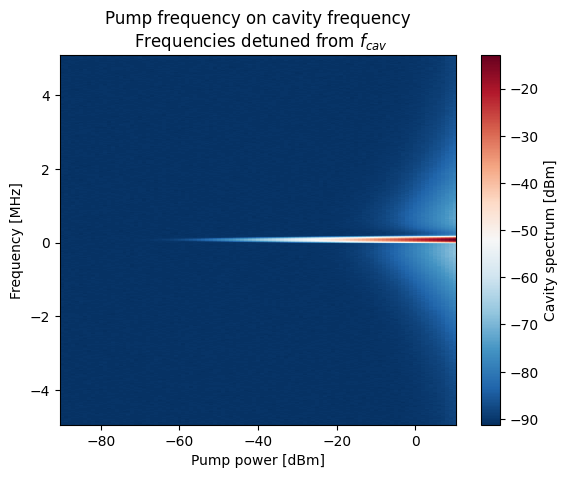

In [120]:
file_folder = '2026-06-30_12.30.48_0004_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
#dx.interactive_linecut_and_colormap(data, initial_var=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Pump power (dBm)':['pump_power', 'dBm', 1]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)

plt.figure()
plt.pcolormesh(data_cavity.pump_power.values, (data_cavity.freq.values - np.full(len(data_cavity.freq.values), fc*1e-09))*1e3, data_cavity.spect.values,
              cmap = 'RdBu_r')
plt.colorbar(label = 'Cavity spectrum [dBm]')
plt.xlabel('Pump power [dBm]')
plt.ylabel('Frequency [MHz]')
plt.title('Pump frequency on cavity frequency\n Frequencies detuned from $f_{cav}$')
plt.show()

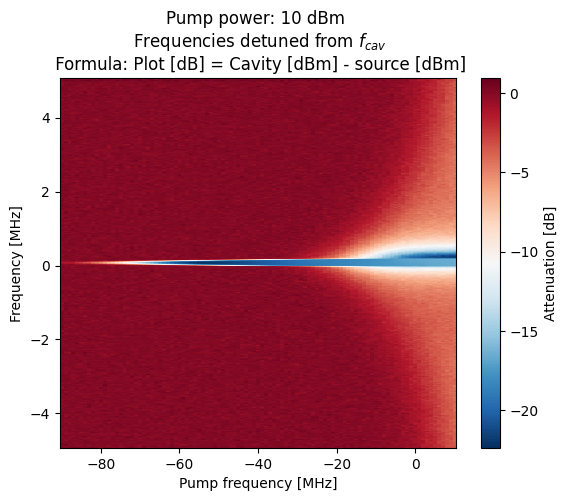

In [121]:
spect_diff = data_cavity.spect.values - data_source.spect.values

plt.figure()
plt.pcolormesh(data_cavity.pump_power.values, (data_cavity.freq.values - np.full(len(data_cavity.freq.values), fc*1e-09))*1e3, spect_diff,
              cmap = 'RdBu_r')
plt.colorbar(label = 'Attenuation [dB]')
plt.xlabel('Pump frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Pump power: 10 dBm \n Frequencies detuned from $f_{cav}$ \n Formula: Plot [dB] = Cavity [dBm] - source [dBm]')
plt.show()

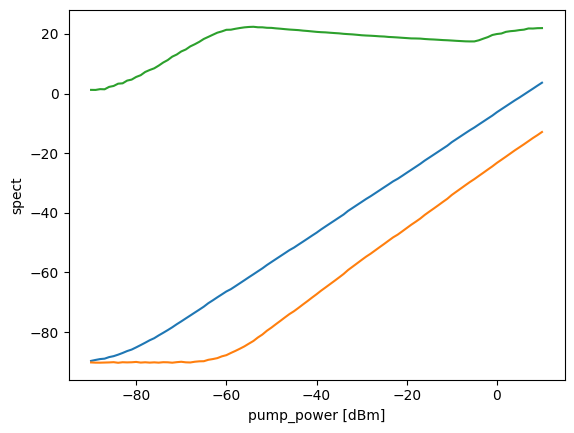

In [129]:
fig, ax = plt.subplots()
data_source.spect.max('freq').plot(ax=ax)
data_cavity.spect.max('freq').plot(ax=ax)
(data_source.spect-data_cavity.spect).max('freq').plot(ax=ax)